In [1]:
from IPython.display import Image

## 3. 영역 연산 

### 0) 학습 목표 

- 필터의 이해 
- 중요한 필터들 

### 1) 필터(컨볼루션/코릴레이션) 

- 일반적인 의미의 필터 
   - 다차원 데이터가 입력되어 일정한 연산을 거친후 출력 데이터를 거칠때, 이를 필터링 한다고 함
   - 이 과정을 담당하는 시스템 (과정) 을 필터라고 함
   - 필터는 입출력 관계가 중첩의 원리가 작용하는 선형 필터와 그렇지 않은 비선형 밒터로 구분
   - 음성등 신호는 1차원이므로 1차원 필터가, 이미지는 2차원 또는 3차원 필터가 사용됨.
   - 2차원 필터는 x축 y축으로 독립적인 필터가 작용되는 것을 다룸(Separable). 아닌 것도 있음  

- 선혈필터 (코릴레이션, 컨볼루션)

    -  입력(보통 다차원)의 각 원소와 다차원 계수값 (필터 $f(cdot)$ 과의 곱의 합으로 구성되는 처리 
    
    -  코릴레이션의  수학적 정의  
       
        $I_{out}(t) =  \sum_{ W \le \tau \le W} x(t - \tau) f(\tau)$  (1차원)
   
        $I_{out} (x, y) =  \sum_{W \le dy \le W } \sum_{ W \le dx \le W}  I_{in}(y- dy, x - dx) f(dy, dx)$  (2차원)
    
    -  콘볼류션의 수학적 정의 (Causual) 
       
        $I_{out}(t) =  \sum_{ 0 \le \tau < t} x(t - \tau) f(\tau)$  (1차원)
   
        $I_{out} (x, y) =  \sum_{0 \le dy < y } \sum_{ 0 \le dx < x}  I_{in}(y- dy, x - dx) f(dy, dx)$  (2차원)
   
   - **주의1**: 책에서는 correlation 의 정의를 사용하고 convolution 이라고 하고 있음. 
   - **주의2**: 책에서는 $f(\cdot)$를 입 출력 신호로 표시하고, $u (\cdot)$를 filter로 표기하는데, 필터는 f(ilter)의 앞자를 따는 것이 바람직함.
   
- 컨볼루션 vs 코릴레이션 
   - 수학적으로는 filter의 인자의 부호만 바뀜 (코릴레이션은 뒤집음) 
   - 최근 많은 문헌들에서 혼용하여 사용
       - 딥러닝의 CNN에서 C가 Convolution은 약자이나 수학적으로는 Correlation 임. 
   - 컨볼류션은 시스템응답 관점에서 입력에 대한 출력과의 관계를 설명할 때 사용 
       - 시점 t의 출력은 $t- \tau$ 시점의 입력 $X(t- \tau)$이 $\tau$ 시점이후에 미치는 영향도인 $f(\tau)$ 를 곱하여 모든 가능한 $\tau$에서 합산
   - 코릴레이션은 두신호 (입력과 필터)의 유사도 (얼마나 비슷한 형태인지) 측정   
       - 1차원에서는 벡터 내적과 유사 
       - t를 기준으로 필터와 입력신호를 곱하여 유사하면 큰 값이 유사도가 낮으면 0 
       
- **결론**

   - 본 수업에서 convolution 은 실제로 correlation 을 의미하며, 일반적인 표현으로 필터라고 사용한다.
   - 주변의 화소들을 일정한 가중치로 곱하고 합쳐서 현재위치희 화소값을 변경함.  

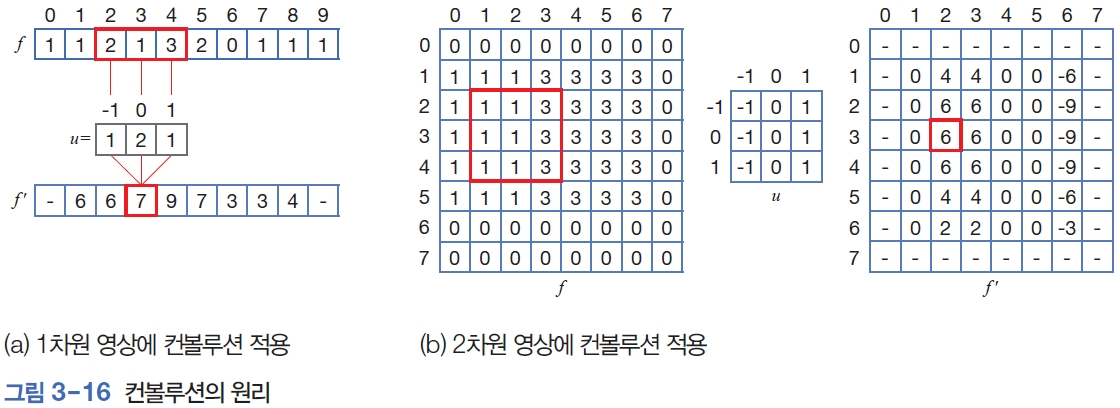

In [2]:
Image("그림 3-16.jpg", width = 720)

### 2) 이미지 처리에서 자주 사용되는 필터들

- 저역 필터 vs 고역 필터

   - 저역 필터 : Box 필터, Gaussian 필터   
   - 고역 필터 : 미분 필터 (새프닝)   
   

- 비선형 필터 
   - median 필터:  중간값을 출력하는 필터 (outlier noise 처리에 효과적)



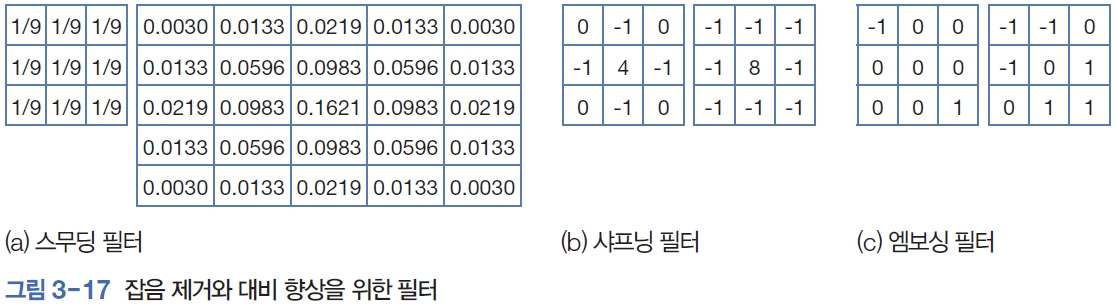

In [3]:
Image("그림 3-17.jpg", width = 720)

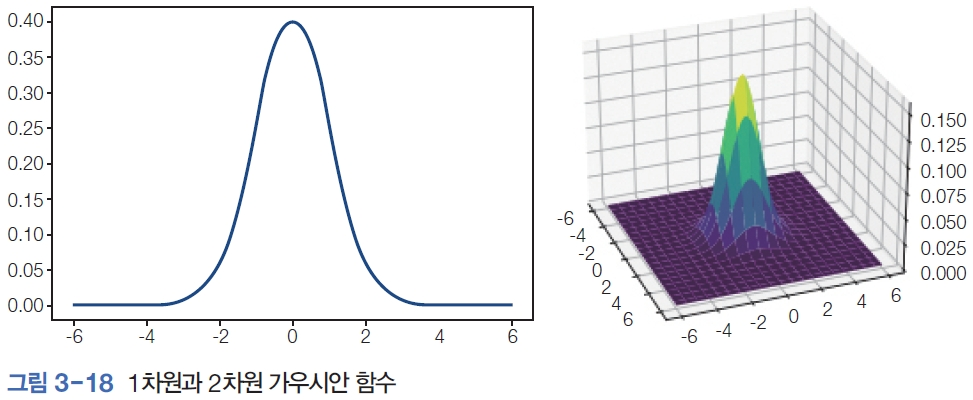

In [4]:
Image("그림 3-18.jpg", width = 720)

### 3)  OpenCV에서 2D filter 사용하기 
 
- 필터 만들기 
   - 필터는 numpy 배열을 사용
   - 직접 함수를 계산하여 만들 거나, 
   - Gaussian등 중요한 함수는 만드는 함수 제공 (cv2.getGaussianKernel())
  
- 필터 적용 하기  
   - 자주 사용하는 필터는 필터링 함수 제공 (cv2.GaussianBlur())
   - 일반적인 경우는 Filter2D 사용 (cv2.filter2D())
   
-** 참고**
   - 가우시안 필터는 이론상 필터의 범위라 무한대 => 현실적으로 계산이 불가능
   - 윈도의 범위 $(-3\sigma, 3\sigma)$ 밖은 값이 매우 작음
       -  99.7% 포함됨  
       -  정확한 계산을 위해서는 커널의 크기를 $6\sigma +1$로 함 
       -  계산 편의상 약간 줄이는 경우도 있음 ($\sigma$ : 68%, $2\sigma$: 95%)       
        

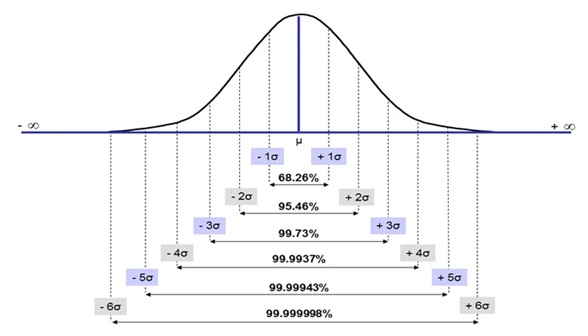

In [5]:
Image("gaussian_sigmas.jpg", width = 480)

(11, 11)
(61, 61)


(<Axes: title={'center': 'gauss u. filter2D'}>,
 Text(0.5, 1.0, 'gauss u. filter2D'),
 (-0.5, 511.5, 511.5, -0.5))

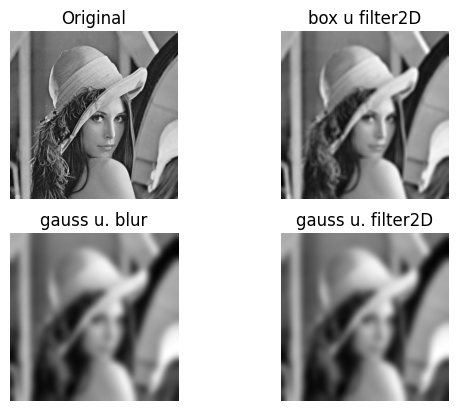

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)

# box filter  
ksize = 11
kernel = np.ones((ksize,ksize),np.float32)/(ksize*ksize)
img_box = cv2.filter2D(img,-1,kernel)  # 주의: ddepth = -1 은 출력 데이터 타입을 입력하고 같게 하겠다는 의미임.
print(kernel.shape)

# gaussian filter 전용함수 사용 
sigma = 10
ksize = sigma*6 + 1
img_g1 = cv2.GaussianBlur(img,(ksize,ksize),sigma)

# 2차원 필터 직접 만들기     
# 1차원 필터를 사용하여 2차원 필터를 만들기 
kernel_1d = cv2.getGaussianKernel(ksize = ksize, sigma = sigma)
kernel = np.outer(kernel_1d, kernel_1d.transpose())
print(kernel.shape)
# 적용 
img_g2 = cv2.filter2D(img,-1,kernel)
    
plt.subplot(2,2,1),plt.imshow(img, cmap='gray'),plt.title('Original'), plt.axis('off')
plt.subplot(2,2,2),plt.imshow(img_box, cmap='gray'),plt.title('box u filter2D'), plt.axis('off')
plt.subplot(2,2,3),plt.imshow(img_g1, cmap='gray'),plt.title('gauss u. blur'), plt.axis('off')
plt.subplot(2,2,4),plt.imshow(img_g2, cmap='gray'),plt.title('gauss u. filter2D'), plt.axis('off')   

#### 끝